Testing out running python code in an isolated Docker container.

Build a simple Agent with code interpreter tool using LangGraph.

# LangGraph Implementation

Implemented a React agent with LangGraph tool node and LangChain core.

Issue: looping between agent and tools node.

In [1]:
from typing import Annotated, TypedDict

from IPython.display import Image, display
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI
from langgraph.graph import END, START, StateGraph
from langgraph.graph.message import add_messages
from langgraph.managed.is_last_step import RemainingSteps
from langgraph.prebuilt import ToolNode

from agent_k.tools.python_code_interpreter import PythonExecTool

PYTHON_AGENT_MODEL = "gpt-4o-mini"

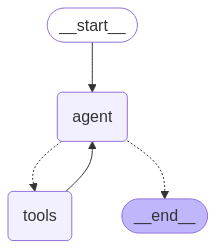

In [ ]:
@tool
def code_interpreter(reflection: str, code: str) -> str:
    """
    Execute the provided Python code in a restricted Docker container and return the output.

    Args:
        reflection: Reasoning on the past messages before generating the code.
        code: The Python code to execute with valid syntax. The last line of the code should be the final calculation result.

    Returns:
        The output of executing the Python code.
    """
    output = PythonExecTool().run({"code": code})
    return output


tools = [code_interpreter]
tool_node = ToolNode(tools)

# Bind the tools to the model
model_with_tools = ChatOpenAI(model=PYTHON_AGENT_MODEL, temperature=0.1).bind_tools(
    tools
)


class State(TypedDict):
    messages: Annotated[list, add_messages]
    remaining_steps: RemainingSteps


def should_continue(state: State):
    messages = state["messages"]
    last_message = messages[-1]

    if last_message.tool_calls and state["remaining_steps"] >= 2:
        return "tools"
    return END


def call_model(state: State):
    messages = state["messages"]
    response = model_with_tools.invoke(messages)
    return {"messages": [response]}


workflow = StateGraph(State)

# Define the two nodes we will cycle between
workflow.add_node("agent", call_model)
workflow.add_node("tools", tool_node)

workflow.add_edge(START, "agent")
workflow.add_conditional_edges("agent", should_continue, ["tools", END])
workflow.add_edge("tools", "agent")

app = workflow.compile()


try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass


def react_agent(system_prompt: str, question: str, recursion_limit: int = 10):
    """
    Run the React agent with code interpreter tool.
    """
    graph = workflow.compile()
    messages = [("system", system_prompt), ("user", question)]
    result = graph.invoke(
        {"messages": messages}, config={"recursion_limit": recursion_limit}
    )

    return result

In [3]:
DEEP_EXTRACTOR_SYSTEM_PROMPT = """You are a helpful AI assistant that answers questions based on the attached NI 43-101 mineral report. Your responses should be grounded in the report's content using the code interpreter tool for numerical calculations.

## Response Workflow:
1. Identify relevant facts in the context needed for answering the question.
2. Perform Aggregations: Use the code interpreter tool for operations like summation, multiplication, or other numerical operations.
3. Structure the Response Correctly: Format your final output with XML tags as follows:
    - Reasoning: Explain your retrieval or computation process within `<thinking>` tags.
    - Code: Show the executed code within `<code>`  tags
    - Final Answer: Provide the final response within `<output>` tags. Do not include other extra XML tags (e.g., `<answer>`) or filler words.

## Key Constraints:
- No Hallucination: If the required information is unavailable, return the default value in the `<output>` tag."""


USER_PROMPT = """You are an assistant for question-answering tasks. Use the following pieces of retrieved context and previous feedback on incorrect answers to answer the question. If you don't know the answer, just return the default value of the field in the question.

Question: What's the total_mineral_resource_tonnage of the mineral site in the attached 43-101 report?
Data type of total_mineral_resource_tonnage: float
Default value of total_mineral_resource_tonnage if not found: 0
Description of total_mineral_resource_tonnage: The total mineral resource tonnage of the mineral site converted to tonnes. The total mineral resource tonnage is calculated by summing up the tonnage of all individual inferred, indicated, and measured mineral resources across all the mineral zones.

Example: if we have 1000 tonnes of inferred mineral resources, 2000 tonnes of indicated mineral resources, and 3000 tonnes of measured mineral resources, the total mineral resource tonnage is 1000 + 2000 + 3000 = 6000 tonnes.

Context: [Document(metadata={'Header 2': '17.10 Mineral Resource Estimate'}, page_content="The following tables presents the updated resource estimate using a cut-off grade of 0.10% sulphide nickel. A total of 24,408 metres of diamond drilling in 117 drill holes were used in the block model estimate. \nTable 17-9 Mineral Resource Estimate - All Zones \n| Cut-off Grade 0.10 % Sulphide Ni | Tonnes (000) | % Sulphide Ni | % Total Ni | % Co |\n|----------------------------------------------|-----------------|-------------------|---------------|--------|\n| Measured | 37,629 | 0.17 | 0.23 | 0.011 |\n| Indicated | 390,934 | 0.17 | 0.22 | 0.011 |\n| Measured + Indicated | 428,563 | 0.17 | 0.22 | 0.011 |\n| Inferred | 742,923 | 0.17 | 0.22 | 0.011 | \nTable 17-10 Mineral Resource by Zone \n| Zone | Class | Tonnes (000's) | % Sulphide Ni | % Total Ni | % Co |\n|------------------------|-----------|-------------------|-------------------|---------------|--------|\n| NORTHWEST Domain 1 | Measured | 11,295 | 0.16 | 0.21 | 0.009 |\n| | Indicated | 115,290 | 0.16 | 0.21 | 0.009 |\n| | Inferred | 143,283 | 0.15 | 0.22 | 0.009 |\n| HORSETRAIL Domain 2+3 | Measured | 26,335 | 0.17 | 0.24 | 0.011 |\n| HORSETRAIL Domain 2+3 | Indicated | 205,131 | 0.17 | 0.24 | 0.011 |\n| HORSETRAIL Domain 2+3 | Inferred | 394,394 | 0.17 | 0.23 | 0.011 |\n| HATZL | Measured | - | - | - | - |\n| Domain 4+5 | Indicated | 61,305 | 0.16 | 0.20 | 0.013 |\n| Domain 4+5 | Inferred | 182,743 | 0.16 | 0.20 | 0.012 |\n| DUFFY | Measured | - | - | - | - |\n| Domain 6 | Indicated | 9,207 | 0.19 | 0.22 | 0.011 |\n| Domain 6 | Inferred | 22,503 | 0.18 | 0.24 | 0.011 |"), Document(metadata={'Header 2': 'Table of Contents'}, page_content='| 1 | SUMMARY AND CONCLUSIONS............................................................................................................ 7 |\n|--------------------------------------------------------------------------------------------------------------------------------------------------------------------|---------------------------------------------------------------------------------------------------------------------------------------------------------------------|\n| 2 | INTRODUCTION AND TERMS OF REFERENCE............................................................................. 8 |\n| 3 | DISCLAIMER.................................................................................................................................................... 8 |\n| 4 | PROPERTY DESCRIPTION AND LOCATION.................................................................................... 8 |\n| 4.1 | Mineral Rights............................................................................................................................................... 8 |\n| 4.2 | Permits & Environmental Liabilities....................................................................................................... 14 |\n| 5 | ACCESSIBILITY, CLIMATE, LOCAL RESOURCES INFRASTRUCTURE AND |\n| PHYSIOGRAPHY................................................................................................................................................... 14 | PHYSIOGRAPHY................................................................................................................................................... 14 |\n| 6 | HISTORY......................................................................................................................................................... 16 |\n| 7 | GEOLOGICAL SETTING.......................................................................................................................... 17 |\n| 7.1 | Regional Geology ....................................................................................................................................... 17 |\n| 7.2 | Local and Property Geology..................................................................................................................... 20 |\n| 8 | DEPOSIT TYPE............................................................................................................................................. 22 |\n| 9 | MINERALIZATION..................................................................................................................................... 22 |\n| 10 | EXPLORATION....................................................................................................................................... 23 |\n| 11 | DRILLING................................................................................................................................................. 28 |\n| 11.1 | Collar Surveying..................................................................................................................................... 30 |\n| 11.2 | Summary and Interpretation of Drilling Results.............................................................................. 33 |\n| 12 | SAMPLING METHOD AND APPROACH...................................................................................... 33 |\n| 13 | SAMPLE PREPARATION, ANALYSES AND SECURITY..........................................................34 |\n| 13.1 | Quality Assurance / Quality Control Program................................................................................. 34 |\n| 14 | DATA VERIFICATION......................................................................................................................... 39 |\n| 14.1 | Core Duplicates ..................................................................................................................................... 39 |\n| 14.2 | Pulp Reject Duplicates.......................................................................................................................... 40 |\n| 14.3 | Coarse Reject Duplicates...................................................................................................................... 43 |\n| 15 | ADJACENT PROPERTIES................................................................................................................... 45 |\n| 16 | MINERAL PROCESSING AND METALLURGICAL TESTING..............................................45 |\n| 17 | MINERAL RESOURCE ESTIMATE.................................................................................................. 47 |\n| 17.1 | Database - General Description......................................................................................................... 47 |\n| 17.2 | Zone Constraints................................................................................................................................... 51 |\n| 17.3 | Density .................................................................................................................................................... 53 |\n| 17.4 | Extreme Grades..................................................................................................................................... 54 |\n| 17.5 | Compositing........................................................................................................................................... 54 |\n| 17.6 | Variogram Analysis ............................................................................................................................... 55 |\n| 17.7 | Block Model and Grade Estimation Procedures.............................................................................. 57 |\n| 17.8 | Mineral Resource Classification .......................................................................................................... 65 |\n| 17.9 | Cut-off Grade Determination ............................................................................................................. 71 |\n| 17.10 | Mineral Resource Estimate.................................................................................................................. 71 |\n| 17.11 | Model Verification................................................................................................................................. 72 |\n| 18 | OTHER RELEVANT DATA AND INFORMATION...................................................................77 |\n| 20 | RECOMMENDATIONS........................................................................................................................ 77 |\n| 21 | REFERENCES.......................................................................................................................................... 78 |')]

---
Now take a deep breath and answer the question again step by step while considering the feedback to the previous incorrect answer."""

if __name__ == "__main__":
    result = react_agent(DEEP_EXTRACTOR_SYSTEM_PROMPT, USER_PROMPT)
    for m in result["messages"]:
        m.pretty_print()

    # Final answer
    print("=" * 100)
    print(result["messages"][-1].content)
    # print(result["messages"][-3].tool_calls[0]["args"]["reflection"])
    # print(result["messages"][-3].tool_calls[0]["args"]["code"])

================================ System Message ================================

You are a helpful AI assistant that answers questions based on the attached NI 43-101 mineral report. Your responses should be grounded in the report's content using the code interpreter tool for numerical calculations.

## Response Workflow:
1. Identify relevant facts in the context needed for answering the question.
2. Perform Aggregations: Use the code interpreter tool for operations like summation, multiplication, or other numerical operations.
3. Structure the Response Correctly: Format your final output with XML tags as follows:
    - Reasoning: Explain your retrieval or computation process within `<thinking>` tags.
    - Code: Show the executed code within `<code>`  tags
    - Final Answer: Provide the final response within `<output>` tags. Do not include other extra XML tags (e.g., `<answer>`) or filler words.

## Key Constraints:
- No Hallucination: If the required information is unavailable, ret

# OpenAI Implementation

Inspired by https://cookbook.openai.com/examples/object_oriented_agentic_approach/secure_code_interpreter_tool_for_llm_agents

In [4]:
# from agent_k.agents.python_code_exec_agent import PythonExecAgent

# agent = PythonExecAgent(
#     model_name="gpt-4o-mini",
#     developer_prompt=DEEP_EXTRACTOR_SYSTEM_PROMPT,
# )

# agent.task(USER_PROMPT, reasoning_effort=None)

In [5]:
# agent.messages.get_messages()